In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -rf "/content/ECG signals"
!cp -r "/content/drive/MyDrive/ECG signals" /content/
!ls /content/"ECG signals"

ptbxl_database.csv  records100	scp_statements.csv


In [ ]:
!ls /content/"ECG signals"

ptbxl_database.csv  records100	scp_statements.csv


In [ ]:
DATA_PATH = "/content/ECG signals/"

In [ ]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 35.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.


In [ ]:
!pip install imbalanced-learn

In [ ]:
import os
import ast
import wfdb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow.keras as keras

sns.set_style('darkgrid')

In [ ]:
PATH_TO_DATA = "/content/ECG signals/"

ECG_df = pd.read_csv(os.path.join(PATH_TO_DATA, 'ptbxl_database.csv'), index_col='ecg_id')
ECG_df.scp_codes = ECG_df.scp_codes.apply(lambda x: ast.literal_eval(x))
ECG_df.patient_id = ECG_df.patient_id.astype(int)
ECG_df.nurse = ECG_df.nurse.astype('Int64')
ECG_df.site = ECG_df.site.astype('Int64')
ECG_df.validated_by = ECG_df.validated_by.astype('Int64')

SCP_df = pd.read_csv(os.path.join(PATH_TO_DATA, 'scp_statements.csv'), index_col=0)
SCP_df = SCP_df[SCP_df.diagnostic == 1]

diagnostic_dict = SCP_df.diagnostic_class.to_dict()

In [ ]:
def diagnostic_class(scp_codes):
    classes = set()
    for code in scp_codes.keys():
        if code in SCP_df.index:
            classes.add(SCP_df.loc[code].diagnostic_class)
    return list(classes)

ECG_df['scp_classes'] = ECG_df.scp_codes.apply(diagnostic_class)
ECG_df[['scp_codes','scp_classes']].head()

,scp_codes,scp_classes
ecg_id,,
1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",[NORM]
2,"{'NORM': 80.0, 'SBRAD': 0.0}",[NORM]
3,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
4,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
5,"{'NORM': 100.0, 'SR': 0.0}",[NORM]


In [ ]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(os.path.join(path, f)) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(os.path.join(path, f)) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

sampling_rate = 100

In [ ]:
ECG_data = np.load("/content/drive/MyDrive/ECG_data.npy")
ECG_data.shape

(21799, 1000, 12)

In [ ]:
priority = ['MI', 'STTC', 'CD', 'HYP', 'NORM']
labels = []

for i in ECG_df.index:
    classes = ECG_df.loc[i].scp_classes

    if len(classes) == 0:
        labels.append('NORM')
    else:
        for p in priority:
            if p in classes:
                labels.append(p)
                break

Z = pd.get_dummies(labels)
Z.index = ECG_df.index

In [ ]:
# enforcing consistent column order so argmax indices are always correct
class_names = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
Z = Z.reindex(columns=class_names, fill_value=0)

In [ ]:
print(Z.sum())

NORM    9480
MI      5469
STTC    3896
CD      2417
HYP      537
dtype: int64


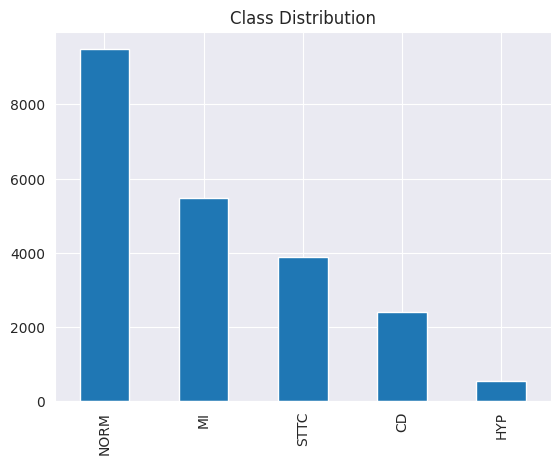

In [ ]:
Z.sum().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

In [ ]:
# binary labels (normal vs abnormal)
binary_labels = []

for i in ECG_df.index:
    classes = ECG_df.loc[i].scp_classes

    if len(classes) == 0 or classes == ['NORM']:
        binary_labels.append(0)
    else:
        binary_labels.append(1)

y_binary = np.array(binary_labels)

In [ ]:
X = pd.DataFrame(index=ECG_df.index)

X['age'] = ECG_df.age
X.age.fillna(0, inplace=True)

X['sex'] = ECG_df.sex.astype(float)
X.sex.fillna(0, inplace=True)

X['height'] = ECG_df.height
X.loc[X.height < 50, 'height'] = np.nan
X.height.fillna(0, inplace=True)

X['weight'] = ECG_df.weight
X.weight.fillna(0, inplace=True)

X['BMI'] = X['weight'] / ((X['height'] / 100) ** 2)
X['BMI'] = X['BMI'].replace([np.inf, -np.inf], 0)
X['BMI'] = X['BMI'].fillna(0)

X['height_norm'] = X['height'] / 200
X['weight_norm'] = X['weight'] / 150

X = X.drop(columns=['height', 'weight'])

X['BMI'] = X['BMI'].replace(0, np.nan)
X['BMI'] = X['BMI'].fillna(X['BMI'].mean())

X['ecg_mean'] = ECG_data.mean(axis=(1,2))
X['ecg_std'] = ECG_data.std(axis=(1,2))

X['has_text'] = 0
X.loc[ECG_df.index[:500], 'has_text'] = 1

X = X.fillna(0)

/tmp/ipykernel_2051/3824877702.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X.age.fillna(0, inplace=True)
/tmp/ipykernel_2051/3824877702.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the origina

In [ ]:
text_data = ECG_df.report.fillna("")

!pip install transformers sentencepiece

from transformers import MarianMTModel, MarianTokenizer

model_name = "Helsinki-NLP/opus-mt-de-en"
tokenizer = MarianTokenizer.from_pretrained(model_name)
translation_model = MarianMTModel.from_pretrained(model_name)

def translate_texts(texts, batch_size=32):
    translated = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size].tolist()
        tokens = tokenizer(batch, return_tensors="pt", padding=True, truncation=True)
        outputs = translation_model.generate(**tokens)
        translated_batch = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        translated.extend(translated_batch)
    return translated

text_data_en = translate_texts(text_data.iloc[:500])
text_data_en = pd.Series(text_data_en)

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 324, in run
    session = self.get_default_session(options)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/index_command.py", line 71, in get_default_session
    self._session = self.enter_context(self._build_session(options))
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/index_command.py", line 100, in _build_session
    session = PipSession(
              ^^^^^^^^^

KeyboardInterrupt: 

In [ ]:
text_clean = pd.read_csv("/content/drive/MyDrive/text_clean_500.csv").iloc[:, 0]
text_clean.head()

0               sinus rhythm peripheral low
1    sinus bradycardia otherwise normal ekg
2                   sinus rhythm normal ekg
3                   sinus rhythm normal ekg
4                   sinus rhythm normal ekg
Name: 0, dtype: str

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

custom_stopwords = {'ekg','ecg','type','otherwise','non','specific'}

def clean_text_advanced(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    words = [
        w for w in words
        if w.isascii()
        and w not in stop_words
        and w not in custom_stopwords
        and len(w) > 2
    ]
    return " ".join(words)

text_clean = text_clean.apply(clean_text_advanced)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from collections import Counter

all_words = []
for text in text_clean:
    words = text.split()
    all_words.extend(words)

word_counts = Counter(all_words)

total_reports = len(text_clean)
total_words = len(all_words)
unique_words = len(word_counts)

report_lengths = [len(t.split()) for t in text_clean]

print("Number of reports:", total_reports)
print("Total words:", total_words)
print("Unique words (vocabulary size):", unique_words)
print("Average words per report:", np.mean(report_lengths))
print("Maximum report length:", np.max(report_lengths))
print("Minimum report length:", np.min(report_lengths))

top_words = word_counts.most_common(20)

print("\nTop 20 most frequent words:")
for word, count in top_words:
    print(word, count)

Number of reports: 500
Total words: 2840
Unique words (vocabulary size): 115
Average words per report: 5.68
Maximum report length: 26
Minimum report length: 0

Top 20 most frequent words:
sinus 412
rhythm 363
normal 263
left 105
nonspecific 47
block 44
abnormal 42
myocardial 42
qrst 38
sinusrytm 38
inferior 37
elaxel 35
right 33
waves 33
atrial 31
due 29
wave 29
avl 27
ventricular 25
segments 25


In [ ]:
ECG_df['report_en'] = None
ECG_df.loc[ECG_df.index[:500], 'report_en'] = text_clean.values

X['report_length'] = 0
X.loc[ECG_df.index[:500], 'report_length'] = text_clean.apply(len).values

In [ ]:
text_full = ["no report"] * len(ECG_df)

for i in range(500):
    text_full[i] = text_clean.iloc[i]

text_full = pd.Series(text_full)

In [ ]:
# Text tokenization and padding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>") # handles unknown words
tokenizer.fit_on_texts(text_full)

sequences = tokenizer.texts_to_sequences(text_full)

text_padded = pad_sequences(sequences, maxlen=max_len, padding='post')
text_padded.shape

(21799, 100)

In [ ]:
# ECG Z-score normalization, also did lead-wise normalization
ECG_data = (ECG_data - ECG_data.mean(axis=1, keepdims=True)) / \
           (ECG_data.std(axis=1, keepdims=True) + 1e-8)

In [ ]:
# Train/validation/test split
import gc

train_idx = ECG_df[ECG_df.strat_fold <= 8].index
val_idx   = ECG_df[ECG_df.strat_fold == 9].index
test_idx  = ECG_df[ECG_df.strat_fold == 10].index

In [ ]:
train_pos = ECG_df.index.get_indexer(train_idx)
val_pos   = ECG_df.index.get_indexer(val_idx)
test_pos  = ECG_df.index.get_indexer(test_idx)

X_ecg_train_full  = ECG_data[train_pos]
X_ecg_val         = ECG_data[val_pos]
X_ecg_test        = ECG_data[test_pos]

X_meta_train_full = X.loc[train_idx].values
X_meta_val        = X.loc[val_idx].values
X_meta_test       = X.loc[test_idx].values

X_text_train_full = text_padded[train_pos]
X_text_val        = text_padded[val_pos]
X_text_test       = text_padded[test_pos]

y_train_raw = Z.loc[train_idx].values
y_val       = Z.loc[val_idx].values
y_test      = Z.loc[test_idx].values

In [ ]:
# Balancing
TARGET = 3500
np.random.seed(42)

y_train_labels = np.argmax(y_train_raw, axis=1)
print("Before balancing:", Counter(y_train_labels))

balanced_idx = []
for cls in range(5):
    idx = np.where(y_train_labels == cls)[0]
    if len(idx) >= TARGET:
        chosen = np.random.choice(idx, TARGET, replace=False) #Majority classes reduced
    else:
        chosen = np.random.choice(idx, TARGET, replace=True) #Minority classes duplicated
    balanced_idx.append(chosen)

balanced_idx = np.concatenate(balanced_idx)
np.random.shuffle(balanced_idx)

X_ecg_train  = X_ecg_train_full[balanced_idx].copy()
X_meta_train = X_meta_train_full[balanced_idx]
X_text_train = X_text_train_full[balanced_idx]
y_train      = y_train_raw[balanced_idx]

noise = np.random.normal(0, 0.005, X_ecg_train.shape) #Adding Gaussian noise
X_ecg_train = X_ecg_train + noise

# Free RAM
del X_ecg_train_full, X_meta_train_full, X_text_train_full, y_train_raw
gc.collect()

print("After balancing:", Counter(np.argmax(y_train, axis=1)))

# Binary splits
y_binary_train = y_binary[train_pos][balanced_idx]
y_binary_val   = y_binary[val_pos]
y_binary_test  = y_binary[test_pos]

# Abnormal masks
train_abn_mask = y_binary_train == 1
val_abn_mask   = y_binary_val == 1
test_abn_mask  = y_binary_test == 1

X_ecg_train_abn  = X_ecg_train[train_abn_mask]
X_meta_train_abn = X_meta_train[train_abn_mask]
X_text_train_abn = X_text_train[train_abn_mask]

X_ecg_val_abn  = X_ecg_val[val_abn_mask]
X_meta_val_abn = X_meta_val[val_abn_mask]
X_text_val_abn = X_text_val[val_abn_mask]

X_ecg_test_abn  = X_ecg_test[test_abn_mask]
X_meta_test_abn = X_meta_test[test_abn_mask]
X_text_test_abn = X_text_test[test_abn_mask]

abn_class_names = ['MI', 'STTC', 'CD', 'HYP']
y_train_abn = y_train[train_abn_mask][:, 1:]
y_val_abn   = y_val[val_abn_mask][:, 1:]
y_test_abn  = y_test[test_abn_mask][:, 1:]

print("Binary train distribution:", Counter(y_binary_train))
print("Abnormal train distribution:", Counter(np.argmax(y_train_abn, axis=1)))

Before balancing: Counter({np.int64(0): 7577, np.int64(1): 4379, np.int64(2): 3131, np.int64(3): 1915, np.int64(4): 416})
After balancing: Counter({np.int64(2): 3500, np.int64(4): 3500, np.int64(0): 3500, np.int64(3): 3500, np.int64(1): 3500})
Binary train distribution: Counter({np.int64(1): 14000, np.int64(0): 3500})
Abnormal train distribution: Counter({np.int64(1): 3500, np.int64(3): 3500, np.int64(2): 3500, np.int64(0): 3500})


In [ ]:
# SMOTE balancing
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.neighbors import NearestNeighbors
import gc

y_train_labels = np.argmax(y_train_raw, axis=1)
print("Before balancing:", Counter(y_train_labels))

X_meta_for_smote = X_meta_train_full.copy()

oversample = SMOTE(sampling_strategy={
    3: 2500,  # CD: from 1915 to 2500
    4: 2500,  # HYP: from 416 to 2500
}, random_state=42, k_neighbors=5)

undersample = RandomUnderSampler(sampling_strategy={
    0: 2500,  # NORM: from 7577 to 2500
    1: 2500,  # MI: from 4379 to 2500
    2: 2500,  # STTC: from 3131 to 2500
}, random_state=42)

# Apply SMOTE to metadata only
X_meta_res, y_res_labels = oversample.fit_resample(X_meta_for_smote, y_train_labels)
X_meta_res, y_res_labels = undersample.fit_resample(X_meta_res, y_res_labels)

print("After SMOTE balancing:", Counter(y_res_labels))

nn = NearestNeighbors(n_neighbors=1)
nn.fit(X_meta_train_full)
_, indices = nn.kneighbors(X_meta_res)
indices = indices.ravel()

# Build final arrays
X_ecg_train  = X_ecg_train_full[indices].copy()
X_text_train = X_text_train_full[indices]
X_meta_train = X_meta_res
y_train      = np.eye(5)[y_res_labels]

# Add noise to ECG
noise = np.random.normal(0, 0.005, X_ecg_train.shape)
X_ecg_train = X_ecg_train + noise

# Free RAM
del X_meta_for_smote, X_meta_res
del X_ecg_train_full, X_meta_train_full, X_text_train_full, y_train_raw
gc.collect()

print("Final shapes ECG:", X_ecg_train.shape,
      "Meta:", X_meta_train.shape,
      "Text:", X_text_train.shape)

# Binary splits
y_binary_train = (np.argmax(y_train, axis=1) != 0).astype(int)
y_binary_val   = y_binary[val_pos]
y_binary_test  = y_binary[test_pos]

# Abnormal masks
train_abn_mask = y_binary_train == 1
val_abn_mask   = y_binary_val == 1
test_abn_mask  = y_binary_test == 1

X_ecg_train_abn  = X_ecg_train[train_abn_mask]
X_meta_train_abn = X_meta_train[train_abn_mask]
X_text_train_abn = X_text_train[train_abn_mask]

X_ecg_val_abn  = X_ecg_val[val_abn_mask]
X_meta_val_abn = X_meta_val[val_abn_mask]
X_text_val_abn = X_text_val[val_abn_mask]

X_ecg_test_abn  = X_ecg_test[test_abn_mask]
X_meta_test_abn = X_meta_test[test_abn_mask]
X_text_test_abn = X_text_test[test_abn_mask]

abn_class_names = ['MI', 'STTC', 'CD', 'HYP']
y_train_abn = y_train[train_abn_mask][:, 1:]
y_val_abn   = y_val[val_abn_mask][:, 1:]
y_test_abn  = y_test[test_abn_mask][:, 1:]

print("Binary train distribution:", Counter(y_binary_train))
print("Abnormal train distribution:", Counter(np.argmax(y_train_abn, axis=1)))

Before balancing: Counter({np.int64(0): 7577, np.int64(1): 4379, np.int64(2): 3131, np.int64(3): 1915, np.int64(4): 416})
After SMOTE balancing: Counter({np.int64(0): 2500, np.int64(1): 2500, np.int64(2): 2500, np.int64(3): 2500, np.int64(4): 2500})
Final shapes ECG: (12500, 1000, 12) Meta: (12500, 9) Text: (12500, 100)
Binary train distribution: Counter({np.int64(1): 10000, np.int64(0): 2500})
Abnormal train distribution: Counter({np.int64(0): 2500, np.int64(1): 2500, np.int64(2): 2500, np.int64(3): 2500})


In [ ]:
print(y_train.shape)
print(y_train[:5])

(17500, 5)
[[False False  True False False]
 [False False False False  True]
 [False False False False  True]
 [ True False False False False]
 [False False False  True False]]


In [ ]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

# Compute balanced class weights to penalize misclassification
# of minority classes proportionally to their frequency
cw_bin = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_binary_train)

class_weight_binary = {0: float(cw_bin[0]), 1: float(cw_bin[1])}

abn_labels_1d = np.argmax(y_train_abn, axis=1)
cw_abn = compute_class_weight('balanced', classes=np.arange(4), y=abn_labels_1d)
class_weight_abn = {i: float(cw_abn[i]) for i in range(4)}

print("Binary class weights:", class_weight_binary)
print("Abnormal class weights:", class_weight_abn)

# Focal loss reduces the contribution of easy-to-classify examples and forces the model to focus on minority classes
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        pt = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_weight = alpha * tf.pow(1.0 - pt, gamma)
        return tf.reduce_mean(focal_weight * ce)
    return loss_fn

def modality_dropout_layer(rate):
    def layer(x):
        mask = tf.cast(
            tf.random.uniform(shape=(tf.shape(x)[0], 1)) > rate,
            tf.float32
        )
        return x * mask
    return Lambda(layer)

# residual block for ECG branch
def residual_conv_block(x, filters, kernel_size=3):
    shortcut = x
    x = Conv1D(filters, kernel_size, padding='same', activation='relu',
               kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Conv1D(filters, kernel_size, padding='same',
               kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)
    x = Add()([x, shortcut])
    return tf.keras.activations.relu(x)

def build_model(output_units, activation, loss):

    #ECG - 1D CNN
    ecg_input = Input(shape=(1000, 12))
    x_ecg = Conv1D(32, 8, activation='relu', padding='same')(ecg_input)
    x_ecg = BatchNormalization()(x_ecg)
    x_ecg = MaxPooling1D(2)(x_ecg) # using maxpool to reduce signal's size

    x_ecg = residual_conv_block(x_ecg, 64)
    x_ecg = MaxPooling1D(2)(x_ecg)

    x_ecg = residual_conv_block(x_ecg, 128)
    x_ecg = MaxPooling1D(2)(x_ecg)

    x_ecg = residual_conv_block(x_ecg, 256)
    x_ecg = GlobalAveragePooling1D()(x_ecg) # better than flatten here
    x_ecg = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x_ecg)
    x_ecg = Dropout(0.3)(x_ecg)
    x_ecg = modality_dropout_layer(0.1)(x_ecg)

    # Metadata - dense network
    meta_input = Input(shape=(X_meta_train.shape[1],))
    x_meta = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(meta_input)
    x_meta = BatchNormalization()(x_meta)
    x_meta = Dropout(0.4)(x_meta)
    x_meta = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x_meta)
    x_meta = modality_dropout_layer(0.2)(x_meta)

    # Text - Embedding and bidirectional LSTM
    text_input = Input(shape=(100,))
    x_text = Embedding(5000, 128, mask_zero=True)(text_input)
    x_text = Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3))(x_text)
    x_text = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x_text)
    x_text = Dropout(0.4)(x_text)
    x_text = modality_dropout_layer(0.3)(x_text)

    # Gated fusion
    proj_dim = 128

    ecg_proj  = LayerNormalization()(Dense(proj_dim, kernel_regularizer=l2(1e-4))(x_ecg))
    meta_proj = LayerNormalization()(Dense(proj_dim, kernel_regularizer=l2(1e-4))(x_meta))
    text_proj = LayerNormalization()(Dense(proj_dim, kernel_regularizer=l2(1e-4))(x_text))

    gate_ecg  = Dense(proj_dim, activation='sigmoid', kernel_regularizer=l2(1e-4))(Dropout(0.1)(ecg_proj))
    gate_meta = Dense(proj_dim, activation='sigmoid', kernel_regularizer=l2(1e-4))(Dropout(0.1)(meta_proj))
    gate_text = Dense(proj_dim, activation='sigmoid', kernel_regularizer=l2(1e-4))(Dropout(0.1)(text_proj))

    ecg_weighted  = Multiply()([ecg_proj,  gate_ecg])
    meta_weighted = Multiply()([meta_proj, gate_meta])
    text_weighted = Multiply()([text_proj, gate_text])

    fusion = Concatenate()([ecg_weighted, meta_weighted, text_weighted])

    x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(fusion)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.3)(x)

    output = Dense(output_units, activation=activation)(x)

    model = Model(
        inputs=[ecg_input, meta_input, text_input],
        outputs=output
    )

    # clipnorm=1.0 prevents exploding gradients
    model.compile(
        optimizer=AdamW(learning_rate=2e-4, clipnorm=1.0), # using AdamW for better regularization
        loss=loss,
        metrics=['accuracy', 'AUC']
    )

    return model

model_binary = build_model(
    output_units=1,
    activation='sigmoid',
    loss='binary_crossentropy'
)

model_abn = build_model(
    output_units=4,
    activation='softmax',
    # focal loss instead of label smoothing better handles HYP/CD minority classes
    loss=focal_loss(gamma=2.0, alpha=0.25)
)

Binary class weights: {0: 2.5, 1: 0.625}
Abnormal class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0}


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    mode='min',
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    restore_best_weights=True
)

# class_weight added to handle normal/abnormal imbalance
model_binary.fit(
    [X_ecg_train, X_meta_train, X_text_train],
    y_binary_train,
    validation_data=([X_ecg_val, X_meta_val, X_text_val], y_binary_val),
    epochs=15,
    batch_size=64,
    class_weight=class_weight_binary,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 419s 1s/step - AUC: 0.7490 - accuracy: 0.6779 - loss: 0.8847 - val_AUC: 0.8470 - val_accuracy: 0.7247 - val_loss: 0.7353 - learning_rate: 2.0000e-04
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 401s 1s/step - AUC: 0.8184 - accuracy: 0.7291 - loss: 0.7596 - val_AUC: 0.8706 - val_accuracy: 0.7907 - val_loss: 0.6619 - learning_rate: 2.0000e-04
Epoch 3/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 389s 1s/step - AUC: 0.8574 - accuracy: 0.7633 - loss: 0.6919 - val_AUC: 0.8918 - val_accuracy: 0.7962 - val_loss: 0.6237 - learning_rate: 2.0000e-04
Epoch 4/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 392s 1s/step - AUC: 0.8863 - accuracy: 0.7801 - loss: 0.6321 - val_AUC: 0.8853 - val_accuracy: 0.8049 - val_loss: 0.6623 - learning_rate: 2.0000e-04
Epoch 5/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - AUC: 0.8973 - accuracy: 0.7948 - loss: 0.6064
Epoch 5: ReduceLROnPlateau reducing learning rate to 5.999999848427251e-05.
274/274 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - AUC: 0.9005 - accuracy: 0

In [ ]:
# To free RAM
del X_ecg_train, X_meta_train, X_text_train
gc.collect()

5366

In [ ]:
model_abn.fit(
    [X_ecg_train_abn, X_meta_train_abn, X_text_train_abn],
    y_train_abn,
    validation_data=([X_ecg_val_abn, X_meta_val_abn, X_text_val_abn], y_val_abn),
    epochs=15,
    batch_size=32,
    class_weight=class_weight_abn,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 398s 836ms/step - AUC: 0.6674 - accuracy: 0.4044 - loss: 0.2767 - val_AUC: 0.8053 - val_accuracy: 0.5390 - val_loss: 0.2305 - learning_rate: 2.0000e-04
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 376s 824ms/step - AUC: 0.7979 - accuracy: 0.5448 - loss: 0.2261 - val_AUC: 0.8367 - val_accuracy: 0.5755 - val_loss: 0.2085 - learning_rate: 2.0000e-04
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 356s 811ms/step - AUC: 0.8491 - accuracy: 0.6101 - loss: 0.1983 - val_AUC: 0.7433 - val_accuracy: 0.4489 - val_loss: 0.2100 - learning_rate: 2.0000e-04
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 359s 820ms/step - AUC: 0.8811 - accuracy: 0.6573 - loss: 0.1760 - val_AUC: 0.8528 - val_accuracy: 0.5698 - val_loss: 0.1701 - learning_rate: 2.0000e-04
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 385s 826ms/step - AUC: 0.8988 - accuracy: 0.6876 - loss: 0.1575 - val_AUC: 0.8384 - val_accuracy: 0.5844 - val_loss: 0.1593 - learning_rate: 2.0000e-04
Epoch 6/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_bin_pred = model_binary.predict(
    [X_ecg_test, X_meta_test, X_text_test]
)

69/69 ━━━━━━━━━━━━━━━━━━━━ 15s 172ms/step


Binary Model (NORMAL vs ABNORMAL)
              precision    recall  f1-score   support

        NORM       0.72      0.86      0.78       952
    ABNORMAL       0.87      0.74      0.80      1246

    accuracy                           0.79      2198
   macro avg       0.80      0.80      0.79      2198
weighted avg       0.81      0.79      0.79      2198



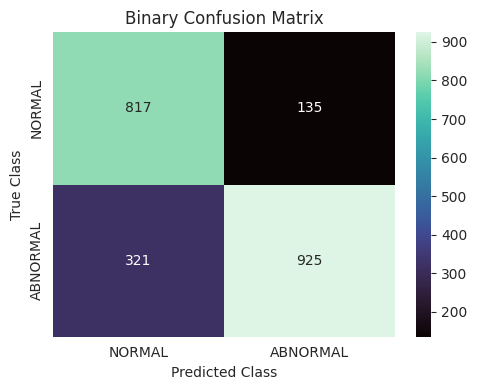

In [ ]:
BINARY_THRESHOLD = 0.5

y_bin_labels = (y_bin_pred.ravel() >= BINARY_THRESHOLD).astype(int)

print("Binary Model (NORMAL vs ABNORMAL)")
print(classification_report(y_binary_test, y_bin_labels,
                             target_names=['NORM', 'ABNORMAL']))

cm_bin = confusion_matrix(y_binary_test, y_bin_labels)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='mako',
            xticklabels=['NORMAL', 'ABNORMAL'],
            yticklabels=['NORMAL', 'ABNORMAL'])
plt.title('Binary Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()

39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 244ms/step
HYP boost=5.0 - recalls per class: [0.37 0.74 0.52 0.61]
HYP boost=6.0 - recalls per class: [0.37 0.73 0.52 0.66]
HYP boost=7.0 - recalls per class: [0.37 0.73 0.52 0.66]
HYP boost=8.0 - recalls per class: [0.37 0.73 0.5  0.68]
HYP boost=9.0 - recalls per class: [0.36 0.73 0.5  0.68]

Abnormal Classifier (MI / STTC / CD / HYP)
              precision    recall  f1-score   support

          MI       0.77      0.58      0.66       550
        STTC       0.59      0.71      0.64       382
          CD       0.74      0.36      0.49       258
         HYP       0.14      0.61      0.22        56

    accuracy                           0.58      1246
   macro avg       0.56      0.56      0.50      1246
weighted avg       0.68      0.58      0.60      1246



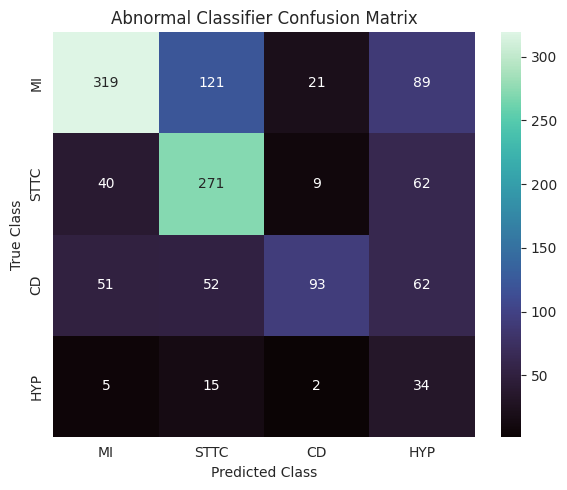

In [ ]:
y_multi_prob = model_abn.predict(
    [X_ecg_test_abn, X_meta_test_abn, X_text_test_abn]
)

for hyp_boost in [5.0, 6.0, 7.0, 8.0, 9.0]:
    boosts = np.array([0.70, 0.80, 1.10, hyp_boost])
    preds = np.argmax(y_multi_prob * boosts, axis=1)
    from sklearn.metrics import recall_score
    recall = recall_score(np.argmax(y_test_abn, axis=1), preds, average=None)
    print(f"HYP boost={hyp_boost:.1f} - recalls per class: {np.round(recall, 2)}")

# boosted HYP a lot
class_boost = np.array([
    1.25,   # MI
    1.05,   # STTC
    0.72,   # CD
    4.20    # HYP
])

y_multi_pred_cls = np.argmax(y_multi_prob * class_boost, axis=1)

print("\nAbnormal Classifier (MI / STTC / CD / HYP)")
print(classification_report(np.argmax(y_test_abn, axis=1),
                             y_multi_pred_cls,
                             target_names=abn_class_names))

cm_abn = confusion_matrix(np.argmax(y_test_abn, axis=1), y_multi_pred_cls)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_abn, annot=True, fmt='d', cmap='mako',
            xticklabels=abn_class_names, yticklabels=abn_class_names)
plt.title('Abnormal Classifier Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()

In [ ]:
abn_pred_idx = np.where(y_bin_pred.ravel() >= BINARY_THRESHOLD)[0]

y_multi_pred_all = model_abn.predict(
    [X_ecg_test[abn_pred_idx],
     X_meta_test[abn_pred_idx],
     X_text_test[abn_pred_idx]]
)


34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 197ms/step


In [ ]:
final_pred = np.zeros(len(y_bin_pred), dtype=int)
# i iterates over y_multi_pred_all rows (0..N-1)
# global_idx is the position in the full test set
for i, global_idx in enumerate(abn_pred_idx):
    final_pred[global_idx] = np.argmax(y_multi_pred_all[i] * class_boost) + 1

y_true = np.argmax(y_test, axis=1)

print("\nCombined Hierarchical")
print(classification_report(y_true, final_pred, target_names=class_names))


Combined Hierarchical
              precision    recall  f1-score   support

        NORM       0.72      0.86      0.78       952
          MI       0.73      0.45      0.56       550
        STTC       0.53      0.55      0.54       382
          CD       0.69      0.31      0.42       258
         HYP       0.04      0.16      0.07        56

    accuracy                           0.62      2198
   macro avg       0.54      0.47      0.47      2198
weighted avg       0.67      0.62      0.62      2198



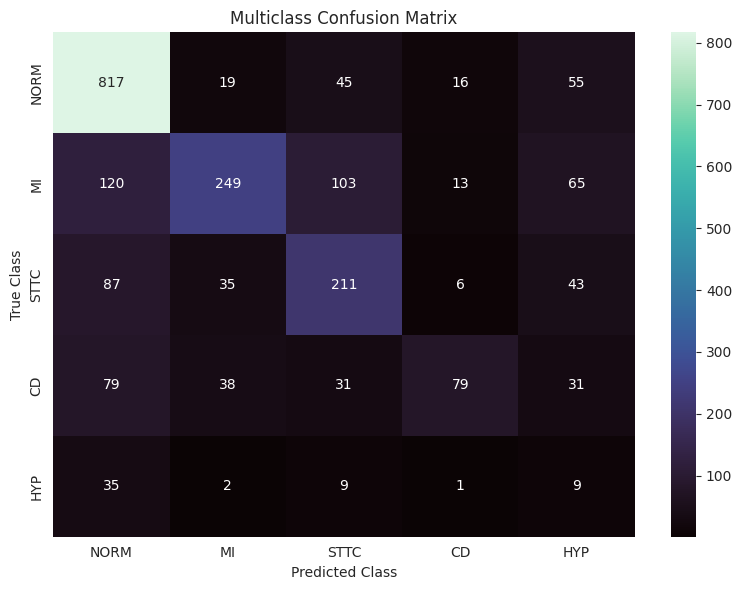

In [ ]:
cm = confusion_matrix(y_true, final_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='mako',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Multiclass Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=f1cc738023059664422fb9d9739ae3cca40b408927b1850017a73090e8828caf
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


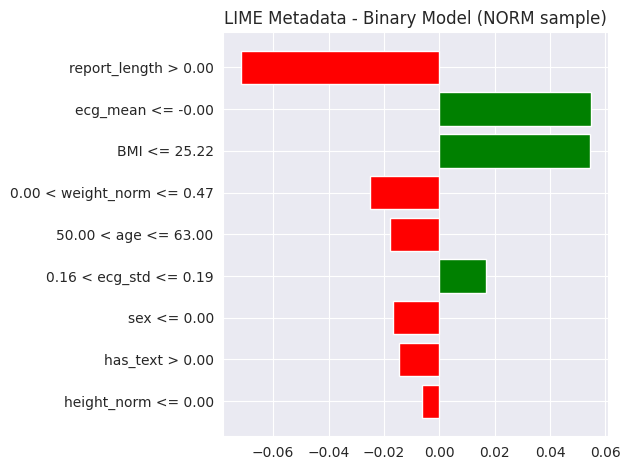

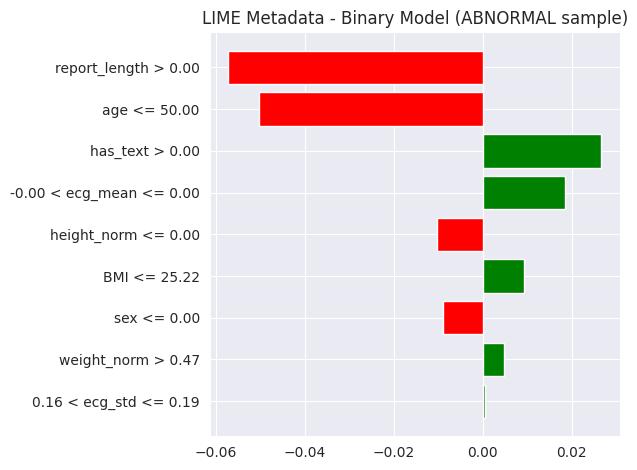

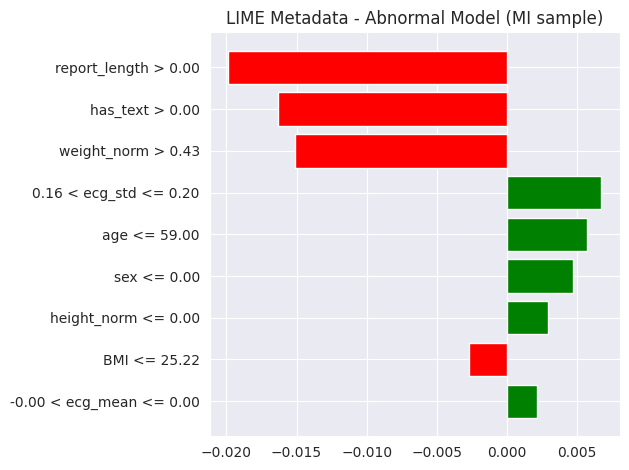

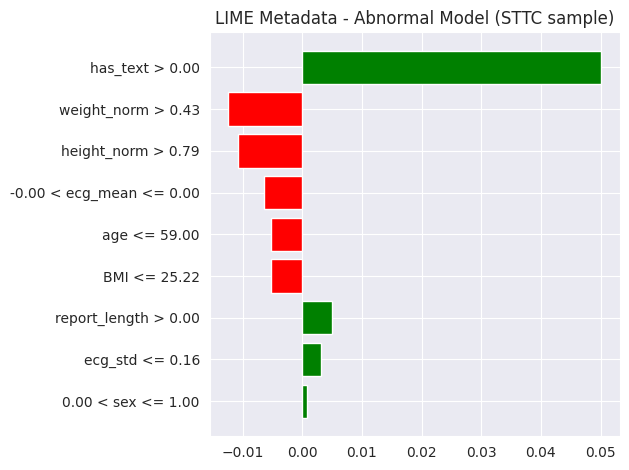

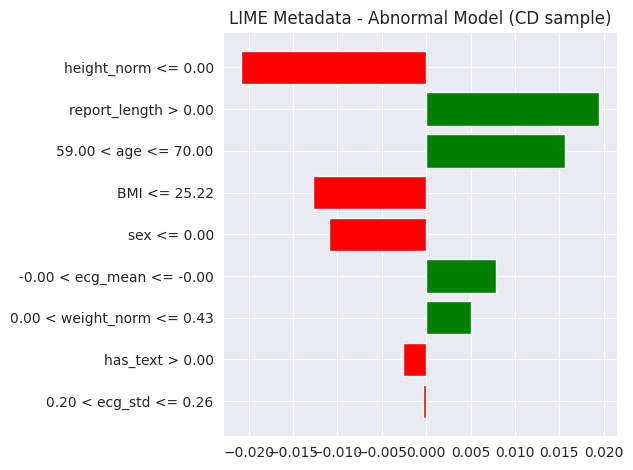

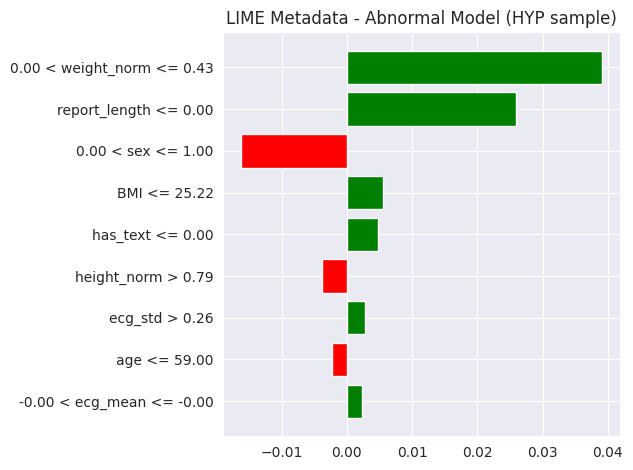

In [ ]:
!pip install lime
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np

# LIME for METADATA

meta_feature_names = [
    'age', 'sex', 'BMI', 'height_norm', 'weight_norm',
    'ecg_mean', 'ecg_std', 'has_text', 'report_length'
]

# Wrapper: perturbs metadata, fixes ECG and text to one sample
def make_binary_meta_predictor(ecg_sample, text_sample):
    def predict(meta_samples):
        n = meta_samples.shape[0]
        ecg_rep  = np.repeat(ecg_sample[np.newaxis], n, axis=0)
        text_rep = np.repeat(text_sample[np.newaxis], n, axis=0)
        preds = model_binary.predict(
            [ecg_rep, meta_samples, text_rep], verbose=0
        )
        return np.hstack([1 - preds, preds])
    return predict

def make_abn_meta_predictor(ecg_sample, text_sample):
    def predict(meta_samples):
        n = meta_samples.shape[0]
        ecg_rep  = np.repeat(ecg_sample[np.newaxis], n, axis=0)
        text_rep = np.repeat(text_sample[np.newaxis], n, axis=0)
        preds = model_abn.predict(
            [ecg_rep, meta_samples, text_rep], verbose=0
        )
        return preds
    return predict

meta_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_meta_test,
    feature_names=meta_feature_names,
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

# Explaining one normal and one abnormal sample
for label_name, mask_val in [('NORM', 0), ('ABNORMAL', 1)]:
    idx = np.where(y_binary_test == mask_val)[0][0]
    predictor = make_binary_meta_predictor(
        X_ecg_test[idx], X_text_test[idx]
    )
    exp = meta_explainer.explain_instance(
        X_meta_test[idx],
        predictor,
        num_features=len(meta_feature_names),
        num_samples=300
    )
    exp.as_pyplot_figure()
    plt.title(f"LIME Metadata - Binary Model ({label_name} sample)")
    plt.tight_layout()
    plt.show()

# Explaining one sample per abnormal class
meta_explainer_abn = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_meta_test_abn,
    feature_names=meta_feature_names,
    mode='classification',
    class_names=abn_class_names,
    discretize_continuous=True,
    random_state=42
)

for cls_idx, cls_name in enumerate(abn_class_names):
    samples = np.where(np.argmax(y_test_abn, axis=1) == cls_idx)[0]
    if len(samples) == 0:
        continue
    idx = samples[0]
    predictor = make_abn_meta_predictor(
        X_ecg_test_abn[idx], X_text_test_abn[idx]
    )
    exp = meta_explainer_abn.explain_instance(
          X_meta_test_abn[idx],
          predictor,
          num_features=len(meta_feature_names),
          num_samples=300,
          top_labels=4  # explain all 4 abnormal classes
    )
    # Get the actual label that LIME saved the explanation under
    available_label = list(exp.as_map().keys())[0]
    exp.as_pyplot_figure(label=available_label)
    plt.title(f"LIME Metadata - Abnormal Model ({cls_name} sample)")
    plt.tight_layout()
    plt.show()


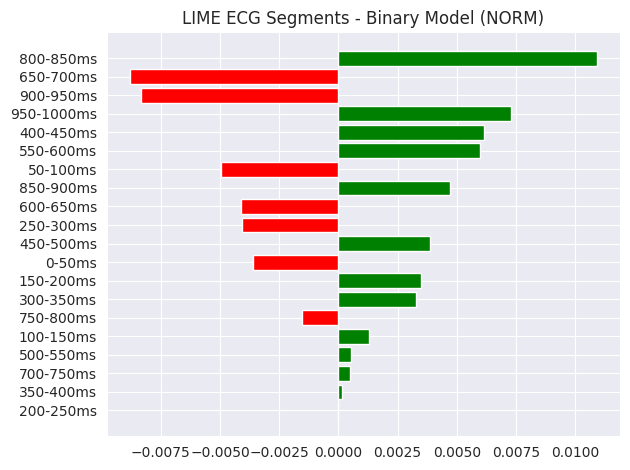

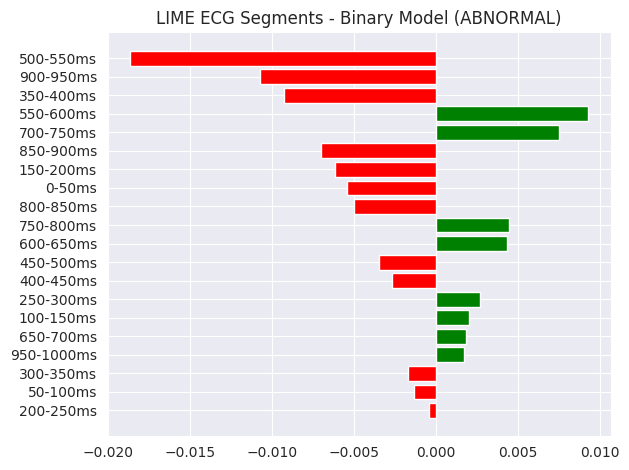

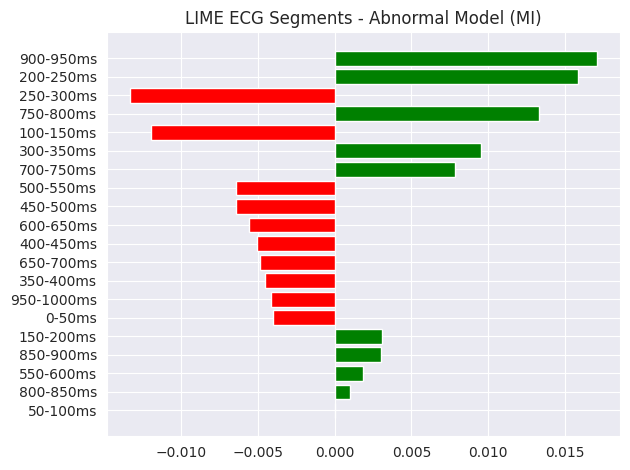

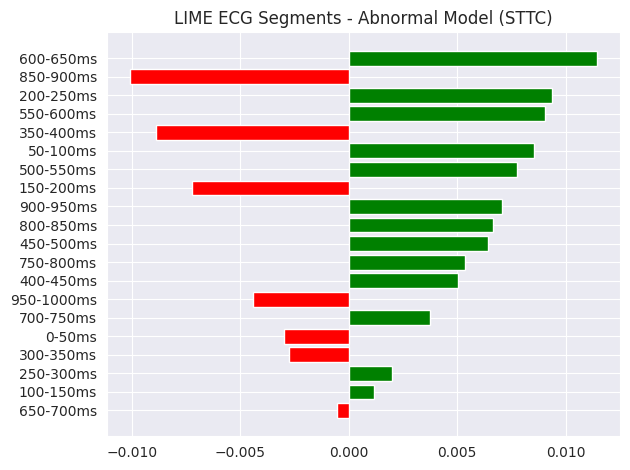

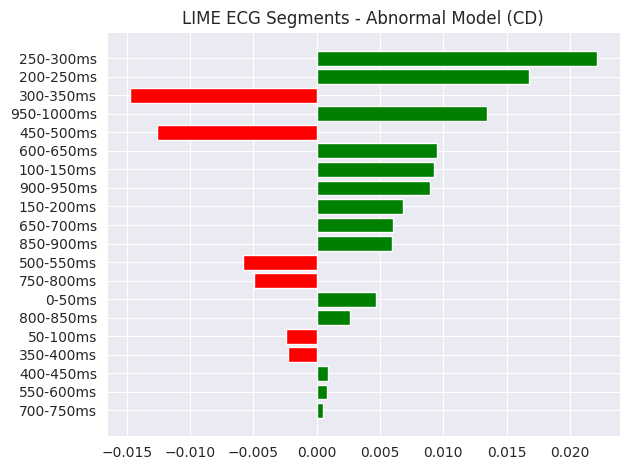

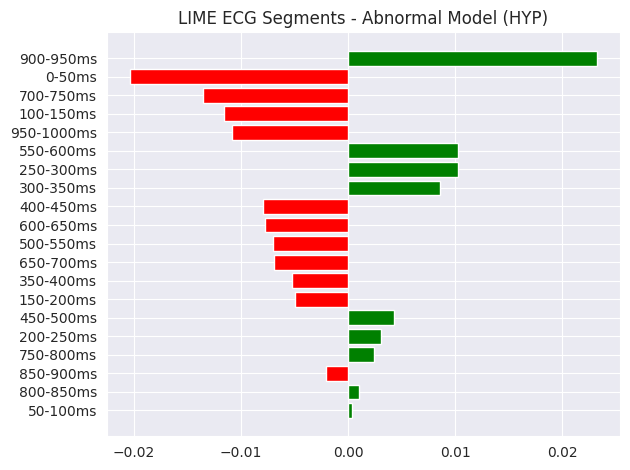

In [ ]:
# LIME for ECG SIGNAL
# Divides ECG signal into time segments and masks them
# Shows which time windows of the ECG are most important for prediction

N_SEGMENTS = 20  # divide 1000 timesteps into 20 segments of 50 each
SEGMENT_LEN = 1000 // N_SEGMENTS  # 50 timesteps per segment

def segment_ecg(ecg, n_segments=N_SEGMENTS):
    """Convert ECG to segment-averaged representation for LIME"""
    segments = []
    for i in range(n_segments):
        start = i * SEGMENT_LEN
        end = start + SEGMENT_LEN
        # Average across all 12 leads for each segment
        segments.append(ecg[start:end, :].mean())
    return np.array(segments)

def reconstruct_ecg_from_mask(original_ecg, mask, n_segments=N_SEGMENTS):
    """Apply LIME mask - zero out masked segments"""
    ecg_copy = original_ecg.copy()
    for i, m in enumerate(mask):
        if m == 0:  # segment is masked out
            start = i * SEGMENT_LEN
            end = start + SEGMENT_LEN
            ecg_copy[start:end, :] = 0.0  # zero out this time window
    return ecg_copy

def make_binary_ecg_predictor(meta_sample, text_sample):
    """Predictor that perturbs ECG segments"""
    def predict(segment_masks):
        # segment_masks shape: (n_perturb, N_SEGMENTS) - binary mask
        batch_ecg = []
        for mask in segment_masks:
            ecg_reconstructed = reconstruct_ecg_from_mask(
                X_ecg_test[ecg_explain_idx], mask
            )
            batch_ecg.append(ecg_reconstructed)
        batch_ecg = np.array(batch_ecg)
        meta_rep  = np.repeat(meta_sample[np.newaxis], len(segment_masks), axis=0)
        text_rep  = np.repeat(text_sample[np.newaxis], len(segment_masks), axis=0)
        preds = model_binary.predict(
            [batch_ecg, meta_rep, text_rep], verbose=0
        )
        return np.hstack([1 - preds, preds])
    return predict

def make_abn_ecg_predictor(meta_sample, text_sample, original_ecg):
    """Predictor for abnormal model that perturbs ECG segments"""
    def predict(segment_masks):
        batch_ecg = []
        for mask in segment_masks:
            ecg_reconstructed = reconstruct_ecg_from_mask(original_ecg, mask)
            batch_ecg.append(ecg_reconstructed)
        batch_ecg = np.array(batch_ecg)
        meta_rep  = np.repeat(meta_sample[np.newaxis], len(segment_masks), axis=0)
        text_rep  = np.repeat(text_sample[np.newaxis], len(segment_masks), axis=0)
        preds = model_abn.predict(
            [batch_ecg, meta_rep, text_rep], verbose=0
        )
        return preds
    return predict

# Segment names for x-axis
segment_names = [f"{i*SEGMENT_LEN}-{(i+1)*SEGMENT_LEN}ms"
                 for i in range(N_SEGMENTS)]

# Build training data for ECG LIME explainer
# Use segment averages of test ECG signals
X_ecg_segmented = np.array([
    segment_ecg(X_ecg_test[i]) for i in range(len(X_ecg_test))
])

ecg_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_ecg_segmented,
    feature_names=segment_names,
    mode='classification',
    discretize_continuous=False,
    random_state=42
)

# Explain binary model ECG for NORM and ABNORMAL
for label_name, mask_val in [('NORM', 0), ('ABNORMAL', 1)]:
    ecg_explain_idx = np.where(y_binary_test == mask_val)[0][0]
    predictor = make_binary_ecg_predictor(
        X_meta_test[ecg_explain_idx],
        X_text_test[ecg_explain_idx]
    )
    exp = ecg_explainer.explain_instance(
        X_ecg_segmented[ecg_explain_idx],
        predictor,
        num_features=N_SEGMENTS,
        num_samples=300
    )
    exp.as_pyplot_figure()
    plt.title(f"LIME ECG Segments - Binary Model ({label_name})")
    plt.tight_layout()
    plt.show()

# Build segmented ECG for abnormal test set
X_ecg_abn_segmented = np.array([
    segment_ecg(X_ecg_test_abn[i]) for i in range(len(X_ecg_test_abn))
])

ecg_explainer_abn = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_ecg_abn_segmented,
    feature_names=segment_names,
    mode='classification',
    class_names=abn_class_names,
    discretize_continuous=False,
    random_state=42
)

# Explain abnormal model ECG for each class
for cls_idx, cls_name in enumerate(abn_class_names):
    samples = np.where(np.argmax(y_test_abn, axis=1) == cls_idx)[0]
    if len(samples) == 0:
        continue
    abn_explain_idx = samples[0]
    predictor = make_abn_ecg_predictor(
        X_meta_test_abn[abn_explain_idx],
        X_text_test_abn[abn_explain_idx],
        X_ecg_test_abn[abn_explain_idx]
    )
    exp = ecg_explainer_abn.explain_instance(
        X_ecg_abn_segmented[abn_explain_idx],
        predictor,
        num_features=N_SEGMENTS,
        num_samples=300,
        top_labels=1
    )
    available_label = list(exp.as_map().keys())[0]
    exp.as_pyplot_figure(label=available_label)
    plt.title(f"LIME ECG Segments - Abnormal Model ({cls_name})")
    plt.tight_layout()
    plt.show()